# 01_exploration.ipynb
# Goal:
# - load CMAPSS FD001
# - inspect dataset structure
# - compute RUL using utility functions
# - visualize some engines/sensors

In [11]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.data_loader import load_cmaps_file
from utils.preprocessing import add_rul

In [12]:
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)
print(RAW_DIR)

/home/flaviu/licenta
/home/flaviu/licenta/data/raw


In [13]:
train_path = RAW_DIR / "train_FD001.txt"
df_train = load_cmaps_file(train_path)

df_train.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
print("Shape:", df_train.shape)
print("Number of engines:", df_train["unit"].nunique())
print("Missing values:", df_train.isna().sum().sum())

Shape: (20631, 26)
Number of engines: 100
Missing values: 0


In [15]:
df_train = add_rul(df_train)
df_train[["unit", "cycle", "RUL"]].head(10)

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [16]:
engine_1 = df_train[df_train["unit"] == 1]
engine_1.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


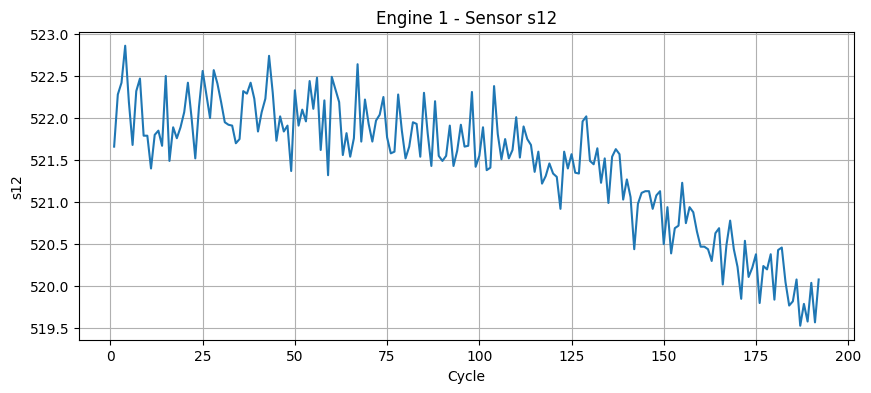

In [17]:
engine_id = 1
subset = df_train[df_train["unit"] == engine_id]

plt.figure(figsize=(10, 4))
plt.plot(subset["cycle"], subset["s12"])
plt.xlabel("Cycle")
plt.ylabel("s12")
plt.title(f"Engine {engine_id} - Sensor s12")
plt.grid(True)
plt.show()

In [10]:
from utils.data_loader import load_cmaps_file
from utils.preprocessing import add_rul

df_train = load_cmaps_file(RAW_DIR / "train_FD001.txt")
df_train = add_rul(df_train)
df_train.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


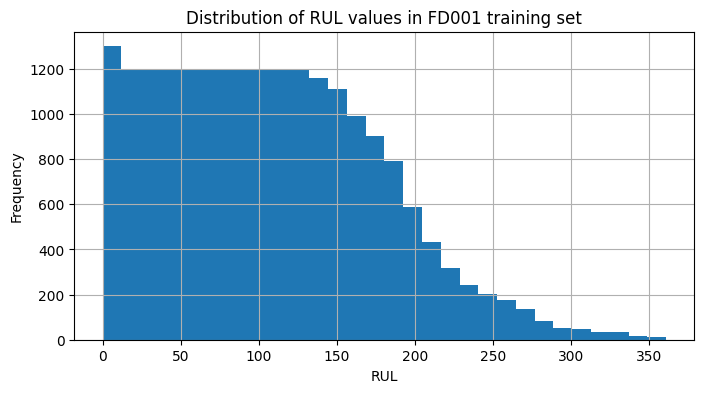

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(df_train["RUL"], bins=30)
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.title("Distribution of RUL values in FD001 training set")
plt.grid(True)
plt.show()

In [19]:
output_path = PROCESSED_DIR / "train_fd001_with_rul.csv"
df_train.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /home/flaviu/licenta/data/processed/train_fd001_with_rul.csv
